# PCA for Dimensionality Reduction in Machine Learning

---

## Objective

---

    In this notebook, we aim to understand `Principal Component Analysis (PCA)`, why it is useful in machine learning, and how to implement it for dimensionality reduction. We will use a real-world dataset to demonstrate the benefits of PCA, visualize the result and assess its impact on model performance.

---

## Introduction

---

Principal Component Analysis (PCA) is an unsupervised statistical technique used to reduce high-dimensional data into fewer dimensions while preserving as much variance as possible. This is done by transforming the original features into a new set of unncorrelated features called principal components.

PCA is widely used in:
* Data Preprocessing and cleaning
* Visualization of high-dimensional data
* Improving model performance and reducing overfitting

---

## Dataset

---

We use the classic Wine Dataset, which includes 13 chemical features of wines derived from three diffrent cultivars. This dataset is ideal for showing how PCA can reduce dimensionality while retaining class separation.

---


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [5]:
# Import dataset
wine = load_wine()
df = pd.DataFrame(wine.data, columns=wine.feature_names)

In [6]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [7]:
df.columns

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='object')

In [8]:
df['target']= wine.target

In [9]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [10]:
df['target']

0      0
1      0
2      0
3      0
4      0
      ..
173    2
174    2
175    2
176    2
177    2
Name: target, Length: 178, dtype: int64

In [12]:
df.shape

(178, 14)

## EDA

---

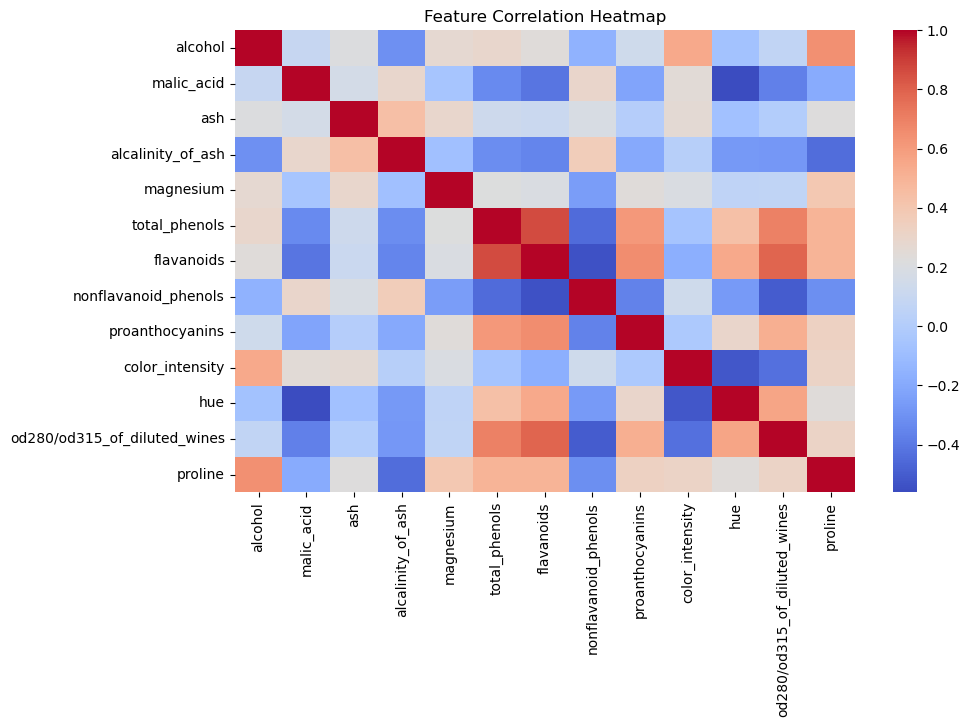

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df.drop('target', axis=1).corr(), annot=False, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [14]:
# Create features and labels
X = df.drop('target', axis=1)
y = df['target']

In [15]:
# Standardized the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Apply PCA

---

In [16]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print('Explained Variance Ratio:', pca.explained_variance_ratio_)

Explained Variance Ratio: [0.36198848 0.1920749 ]


###  💡 What is Explained Variance Ratio in PCA?
* PCA transforms your original featuresi nto a new set of uncorrelated variables called principal components.
* These components are ordered by how much variance they capture from the data
* `Variance` - how much teh data spreads out. More variance, more information captured
* The explained variance ratio tells you how much of the total data variance each principal components explains.
> The first principal component `36.2%`  is the total variance of your original 13-features dataset <br>
> The second principal component `19.2% `

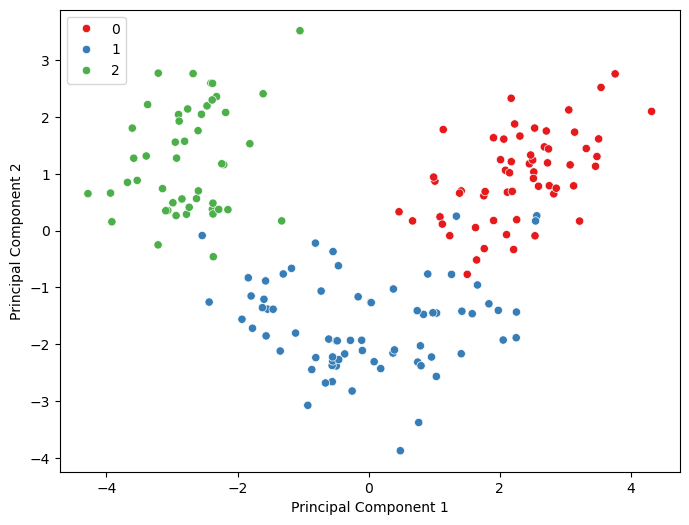

In [17]:
## Visualization of PCA Components
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['target'] = y

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, 
                x='PC1', 
                y='PC2',
                hue='target',
                palette='Set1')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

In [18]:
## Split the data into train and test set

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

In [19]:
#Instantiate the model
clf = RandomForestClassifier(random_state=42)

In [20]:
#Fit the model
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [21]:
#Make a prediction
y_preds = clf.predict(X_test)

In [22]:
y_preds

array([0, 0, 2, 0, 1, 0, 1, 2, 1, 2, 0, 2, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 2, 2, 2, 1, 1, 1, 0, 0, 1, 2, 0, 0, 0])

In [24]:
#Show the accuracy
print('Accuracy with Original Features: ', accuracy_score(y_test, y_preds))

Accuracy with Original Features:  1.0


In [27]:
# Train on PCA-reduced Data
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca,
                                                                    y,
                                                                    test_size=0.2,
                                                                    random_state=42)

In [28]:
clf_pca = RandomForestClassifier(random_state=42)
clf_pca.fit(X_train_pca, y_train_pca)

RandomForestClassifier(random_state=42)

In [30]:
#Evaluate the model in pca test data
clf_pca.score(X_test_pca, y_test_pca)

1.0

In [31]:
#predict the model
y_preds_pca = clf_pca.predict(X_test_pca)

In [32]:
y_preds_pca

array([0, 0, 2, 0, 1, 0, 1, 2, 1, 2, 0, 2, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 2, 2, 2, 1, 1, 1, 0, 0, 1, 2, 0, 0, 0])

In [34]:
#Check the accuracy
print('Accuracy with PCA Features:', accuracy_score(y_test_pca, y_preds_pca))

Accuracy with PCA Features: 1.0


### Insights

* > PCA reduced 13 features to 2 while retaining most of the variance (~56%).
* > The Random Forest classifier maintained high accuracy even with reduced dimensions.
* > PCA visualization clearly separates the wine classes, showing good feature preservation.

## Conclusion

---

`PCA` is a powerful tool for simplifying high-dimensional datasets. It helps reduce noise and computational costs
while retaining the essence of the data. In our example, PCA significantly reduced dimensions from 13 to 2,
yet our classifier performed nearly as well as with the full feature set.

Such dimensionality reduction is highly beneficial when working with large-scale or high-dimensional data in practice.